## <center> Assignment 4. Sarcasm detection with logistic regression
    
We'll be using the dataset from the [paper](https://arxiv.org/abs/1704.05579) "A Large Self-Annotated Corpus for Sarcasm" with >1mln comments from Reddit, labeled as either sarcastic or not. A processed version can be found on Kaggle in a form of a [Kaggle Dataset](https://www.kaggle.com/danofer/sarcasm).

Sarcasm detection is easy. 

<img src="https://habrastorage.org/webt/1f/0d/ta/1f0dtavsd14ncf17gbsy1cvoga4.jpeg" />

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

In [2]:
#!pip install matplotlib

In [2]:
pd.set_option("max_colwidth",200)

In [7]:
df = pd.read_csv(r"data/train-balanced-sarcasm.csv")
df

,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
0,0,NC and NH.,Trumpbart,politics,2,-1,-1,2016-10,2016-10-16 23:55:23,"Yeah, I get that argument. At this point, I'd prefer is she lived in NC as well."
1,0,You do know west teams play against west teams more than east teams right?,Shbshb906,nba,-4,-1,-1,2016-11,2016-11-01 00:24:10,The blazers and Mavericks (The wests 5 and 6 seed) did not even carry a good enough record to make the playoffs in the east last year.
2,0,"They were underdogs earlier today, but since Gronk's announcement this afternoon, the Vegas line has moved to patriots -1",Creepeth,nfl,3,3,0,2016-09,2016-09-22 21:45:37,They're favored to win.
3,0,"This meme isn't funny none of the ""new york nigga"" ones are.",icebrotha,BlackPeopleTwitter,-8,-1,-1,2016-10,2016-10-18 21:03:47,deadass don't kill my buzz
4,0,I could use one of those tools.,cush2push,MaddenUltimateTeam,6,-1,-1,2016-12,2016-12-30 17:00:13,Yep can confirm I saw the tool they use for that. It was made by our boy EASports_MUT
...,...,...,...,...,...,...,...,...,...,...
1010821,1,I'm sure that Iran and N. Korea have the technology to create a pig/bird/human hybrid virus.,TwarkMain,reddit.com,2,2,0,2009-04,2009-04-25 00:47:52,"No one is calling this an engineered pathogen, but there are reports that this virus has bits of human, pig and bird genetic material, which makes it uniquely interesting"
1010822,1,"whatever you do, don't vote green!",BCHarvey,climate,1,1,0,2009-05,2009-05-14 22:27:40,"In a move typical of their recent do-nothing approach to CO2 emissions, Canada appoints a tar sands executive to liaise with the US on climate change"
1010823,1,Perhaps this is an atheist conspiracy to make Christians look bad?,rebelcommander,atheism,1,1,0,2009-01,2009-01-11 00:22:57,Screw the Disabled--I've got to get to Church on Time
1010824,1,The Slavs got their own country - it is called Kosovo,catsi,worldnews,1,1,0,2009-01,2009-01-23 21:12:49,"I've always been unsettled by that. I hear a lot of Jewish people say that Israel can do whatever it pleases because of the holocaust, but the Slavs, and other races the Germans attempted to annih..."


# Detección de sarcasmo
Para este ejercicio vas a utilizar el dataset del paper [A Large Self-Annotated Corpus for Sarcasm](https://arxiv.org/abs/1704.05579), con un millón de comentarios de Reddit, etiquetados como sarcásticos o no sarcásticos. Se pide:
1. Si hubiese missings, eliminalos


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010826 entries, 0 to 1010825
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   label           1010826 non-null  int64 
 1   comment         1010771 non-null  object
 2   author          1010826 non-null  object
 3   subreddit       1010826 non-null  object
 4   score           1010826 non-null  int64 
 5   ups             1010826 non-null  int64 
 6   downs           1010826 non-null  int64 
 7   date            1010826 non-null  object
 8   created_utc     1010826 non-null  object
 9   parent_comment  1010826 non-null  object
dtypes: int64(4), object(6)
memory usage: 77.1+ MB


In [9]:
# hay algunos nulos en comment
df = df.dropna()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1010771 entries, 0 to 1010825
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   label           1010771 non-null  int64 
 1   comment         1010771 non-null  object
 2   author          1010771 non-null  object
 3   subreddit       1010771 non-null  object
 4   score           1010771 non-null  int64 
 5   ups             1010771 non-null  int64 
 6   downs           1010771 non-null  int64 
 7   date            1010771 non-null  object
 8   created_utc     1010771 non-null  object
 9   parent_comment  1010771 non-null  object
dtypes: int64(4), object(6)
memory usage: 84.8+ MB


2. Comprueba que está balanceado

In [ ]:
df['label'].value_counts()
# Es casi el 50% cada

label
0    505403
1    505368
Name: count, dtype: int64

3. Divide el dataset en train test. Qué forma tienen?

In [14]:
from sklearn.model_selection import train_test_split
X = df [['comment']]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(808616, 1)
(202155, 1)
(808616,)
(202155,)


## Tasks:
1. Analyze the dataset, make some plots. This [Kernel](https://www.kaggle.com/sudalairajkumar/simple-exploration-notebook-qiqc) might serve as an example
2. Build a Tf-Idf + logistic regression pipeline to predict sarcasm (`label`) based on the text of a comment on Reddit (`comment`).
3. Plot the words/bigrams which a most predictive of sarcasm 

In [14]:
str(df[df['label']==0]['comment'])

'0                                                                                                                                                         nc and nh.\n1                                                                                         you do know west teams play against west teams more than east teams right?\n2                                          they were underdogs earlier today, but since gronk\'s announcement this afternoon, the vegas line has moved to patriots -1\n3                                                                                                       this meme isn\'t funny none of the "new york nigga" ones are.\n4                                                                                                                                    i could use one of those tools.\n                                                                                     ...                                                                            \n1

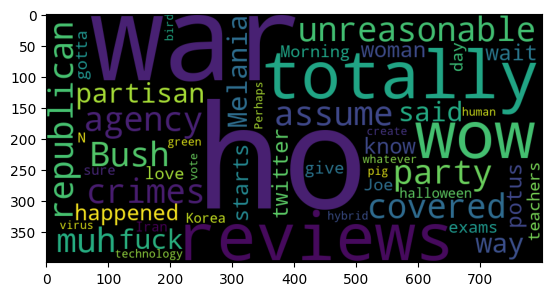

In [ ]:

wordcloud = WordCloud(background_color='black',
                stopwords = STOPWORDS, #excluyendo stepwords
                max_words = 50, # como máximo 50 stopwords
                # max_font_size = max_font_size, 
                random_state = 42,
                width=800, 
                height=400)
#Creamos una nube de palabras para ver cuales son las que más se repiten en los comentarios sarcásticos
wordcloud.generate(str(df[df['label']==1]['comment']))
plt.imshow(wordcloud)

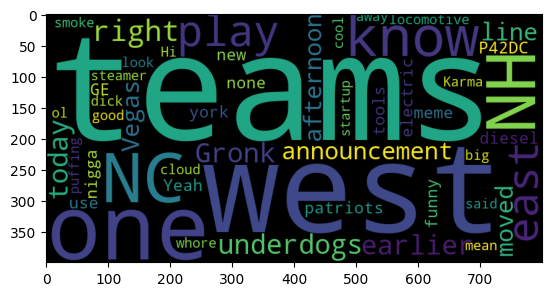

In [20]:
wordcloud = WordCloud(background_color='black',
                stopwords = STOPWORDS,
                max_words = 50,
                # max_font_size = max_font_size, 
                random_state = 42,
                width=800, 
                height=400)
wordcloud.generate(str(df[df['label']==0]['comment']))
plt.imshow(wordcloud)

In [26]:
import plotly.graph_objs as go
from plotly import tools
import plotly.offline as py

In [ ]:
# SIguiendo el kaggle de ejemplo: 
from collections import defaultdict

train1_df = df[df["label"]==1]
train0_df = df[df["label"]==0]

## custom function for ngram generation ##
def generate_ngrams(text, n_gram=1):
    # solo la añades a la lista si no está en stopwords
    token = [token for token in text.lower().split(" ") if token != "" if token not in STOPWORDS]
    ngrams = zip(*[token[i:] for i in range(n_gram)])
    return [" ".join(ngram) for ngram in ngrams]

## custom function for horizontal bar chart ##
def horizontal_bar_chart(df, color):
    trace = go.Bar(
        y=df["word"].values[::-1],
        x=df["wordcount"].values[::-1],
        showlegend=False,
        orientation = 'h',
        marker=dict(
            color=color,
        ),
    )
    return trace

## Get the bar chart from sincere questions ##
freq_dict = defaultdict(int)
for sent in train0_df["comment"]:
    for word in generate_ngrams(sent):
        freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace0 = horizontal_bar_chart(fd_sorted.head(50), 'blue')

## Get the bar chart from insincere questions ##
freq_dict = defaultdict(int)
for sent in train1_df["comment"]:
    for word in generate_ngrams(sent):
        freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace1 = horizontal_bar_chart(fd_sorted.head(50), 'blue')

# Creating two subplots
fig = tools.make_subplots(rows=1, cols=2, vertical_spacing=0.04,
                          subplot_titles=["Frequent words of sincere questions", 
                                          "Frequent words of insincere questions"])
fig.append_trace(trace0, 1, 1)
fig.append_trace(trace1, 1, 2)
fig['layout'].update(height=1200, width=900, paper_bgcolor='rgb(233,233,233)', title="Word Count Plots")
py.iplot(fig, filename='word-plots')

#plt.figure(figsize=(10,16))
#sns.barplot(x="ngram_count", y="ngram", data=fd_sorted.loc[:50,:], color="b")
#plt.title("Frequent words for Insincere Questions", fontsize=16)
#plt.show()


c:\Users\NaiaJon\AppData\Local\Programs\Python\Python311\Lib\site-packages\plotly\tools.py:445: DeprecationWarning: plotly.tools.make_subplots is deprecated, please use plotly.subplots.make_subplots instead
  warnings.warn(


In [ ]:
#Varias palabras de las que más aparecen están en el top en ambas (con sarcasmo y sin sarcasmo): will,
# people, one, know...

In [43]:
# Ahora hacemos lo mismo con bigrams

freq_dict = defaultdict(int)
for sent in train0_df["comment"]:
    for word in generate_ngrams(sent,2):
        freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace0 = horizontal_bar_chart(fd_sorted.head(50), 'orange')


freq_dict = defaultdict(int)
for sent in train1_df["comment"]:
    for word in generate_ngrams(sent,2):
        freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace1 = horizontal_bar_chart(fd_sorted.head(50), 'orange')

# Creating two subplots
fig = tools.make_subplots(rows=1, cols=2, vertical_spacing=0.04,horizontal_spacing=0.15,
                          subplot_titles=["Frequent bigrams of sincere questions", 
                                          "Frequent bigrams of insincere questions"])
fig.append_trace(trace0, 1, 1)
fig.append_trace(trace1, 1, 2)
fig['layout'].update(height=1200, width=900, paper_bgcolor='rgb(233,233,233)', title="Bigram Count Plots")
py.iplot(fig, filename='word-plots')


c:\Users\NaiaJon\AppData\Local\Programs\Python\Python311\Lib\site-packages\plotly\tools.py:445: DeprecationWarning: plotly.tools.make_subplots is deprecated, please use plotly.subplots.make_subplots instead
  warnings.warn(


In [30]:
# Y lo mismo para trigrams

freq_dict = defaultdict(int)
for sent in train0_df["comment"]:
    for word in generate_ngrams(sent,3):
        freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace0 = horizontal_bar_chart(fd_sorted.head(50), 'green')


freq_dict = defaultdict(int)
for sent in train1_df["comment"]:
    for word in generate_ngrams(sent,3):
        freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace1 = horizontal_bar_chart(fd_sorted.head(50), 'green')

# Creating two subplots
fig = tools.make_subplots(rows=1, cols=2, vertical_spacing=0.04, horizontal_spacing=0.2,
                          subplot_titles=["Frequent trigrams of sincere questions", 
                                          "Frequent trigrams of insincere questions"])
fig.append_trace(trace0, 1, 1)
fig.append_trace(trace1, 1, 2)
fig['layout'].update(height=1200, width=1200, paper_bgcolor='rgb(233,233,233)', title="Trigram Count Plots")
py.iplot(fig, filename='word-plots')

c:\Users\NaiaJon\AppData\Local\Programs\Python\Python311\Lib\site-packages\plotly\tools.py:445: DeprecationWarning: plotly.tools.make_subplots is deprecated, please use plotly.subplots.make_subplots instead
  warnings.warn(


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
# Hacemos el modelo

# Primero creamos los vectores tfidf
# le digo que me coja los ngramas de 1 a 3. Son un montón de features, por eso lo limito a 50000
tfidf_vec = TfidfVectorizer(stop_words='english', ngram_range=(1,3), max_features=50000)
tfidf_vec.fit_transform(X_train['comment'].values.tolist() + X_test['comment'].values.tolist())
train_tfidf = tfidf_vec.transform(X_train['comment'].values.tolist())
test_tfidf = tfidf_vec.transform(X_test['comment'].values.tolist())

In [33]:

# definimos el modelo y lo entrenamos con la muestra vectorizada
model = LogisticRegression(C=5., solver='sag')
model.fit(train_tfidf, y_train)
y_pred = model.predict(test_tfidf)#[:,1]

print("accuracy_score", accuracy_score(y_test, y_pred))
print("confusion_matrix\n", confusion_matrix(y_test, y_pred))

accuracy_score 0.6807697064133956
confusion_matrix
 [[74757 26259]
 [38275 62864]]


In [ ]:
# Bueeeeeeno..... empiezo a acostumbrarme a accuracies de 0.60 y pico pero sospecho que no es lo ideal.

In [ ]:
# Está entrenado con el vectorizador así que hay que transformar los textos a predecir
texto_vectorizado = tfidf_vec.transform(["I love Trump"])
model.predict_proba(texto_vectorizado)
# Igual no es tan tonto... esto lo pilla :-)

array([[0.24831208, 0.75168792]])

In [ ]:
texto_vectorizado = tfidf_vec.transform(["Yes, sure..."])
model.predict_proba(texto_vectorizado)
# Casi 100 que es sarcástico

array([[0.00141626, 0.99858374]])

In [39]:
texto_vectorizado = tfidf_vec.transform(["I have some problems resolving this"])
model.predict_proba(texto_vectorizado)

array([[0.60192599, 0.39807401]])

In [42]:
texto_vectorizado = tfidf_vec.transform(["make america great again"])
model.predict_proba(texto_vectorizado)

array([[0.24024746, 0.75975254]])

3. Plot the words/bigrams which a most predictive of sarcasm 

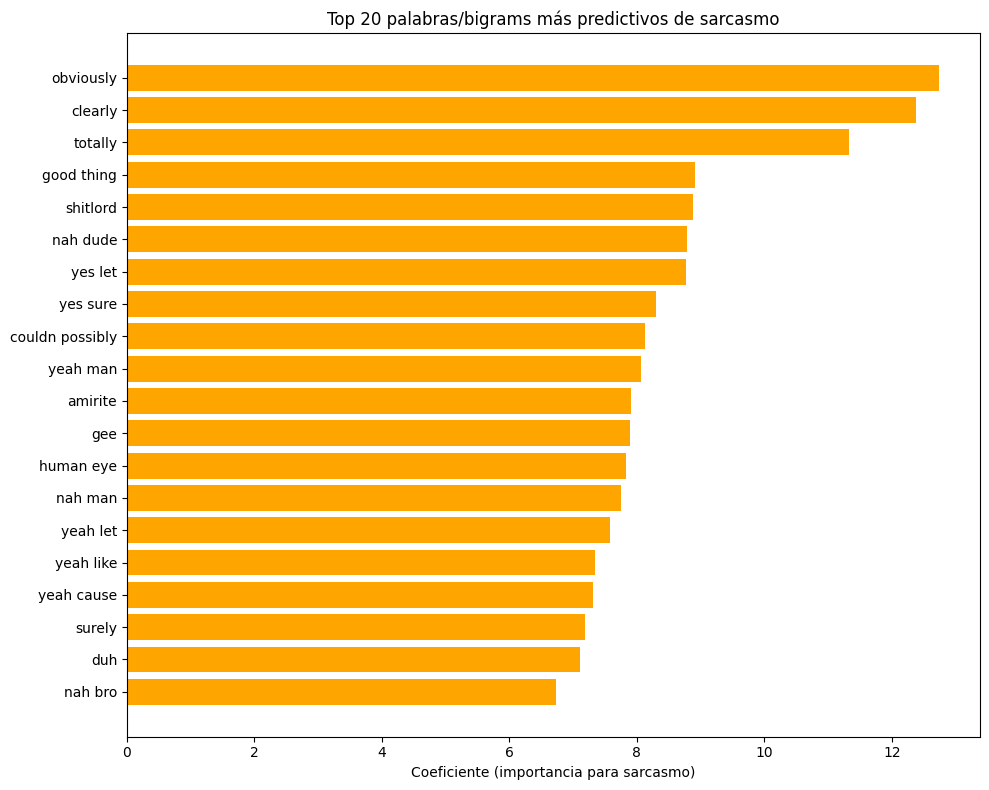

In [44]:
# Obtener coeficientes del modelo
coefs = model.coef_[0]  # Si es binario

# Crear DataFrame con palabras y coeficientes
feature_importance = pd.DataFrame({
    'word': tfidf_vec.get_feature_names_out(),  # tus n-gramas
    'coef': coefs
})

# Ordenar por coeficiente (más predictivo de sarcasmo, label=1)
feature_importance_sorted = feature_importance.sort_values('coef', ascending=False)

# Graficar top 20 más predictivos
top_predictive = feature_importance_sorted.head(20)

plt.figure(figsize=(10, 8))
plt.barh(top_predictive['word'], top_predictive['coef'], color='orange')
plt.xlabel('Coeficiente (importancia para sarcasmo)')
plt.title('Top 20 palabras/bigrams más predictivos de sarcasmo')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()